In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

## Minimization of the Relative Cost Ratio

In this example, we will use the `minimum_cost.py` module to find the empirical design that offers the best balance between statistical efficiency and economic cost. 

When evaluating the cost ratio, we penalize the standard efficiencies of the design. Mathematically, the penalty formulas must take into account that the degree (or order) of homogeneity of an optimality criterion $\Phi$ is denoted by the letter $s$. The functions in our module (such as `cost_ratio_A` or `cost_ratio_E`) already manage the weighting of this degree of homogeneity internally to return the correctly adjusted ratio.

Below, we will evaluate a grid of induction values $g_0$ for a logistic model with $\Gamma = 0.5$ under the A-optimal criterion, extracting both the ideal design and the minimization curve.

--- Minimum Cost Analysis for the A-optimal Criterion ---
Model: Logistic | Gamma: 0.5

Maximum response value ($\Gamma_0$) found: 0.58
Minimum cost ratio achieved: 0.8605

Minimum cost design (Probability -> Weight):
-0.603850    0.471
 0.080693    0.529
dtype: float64


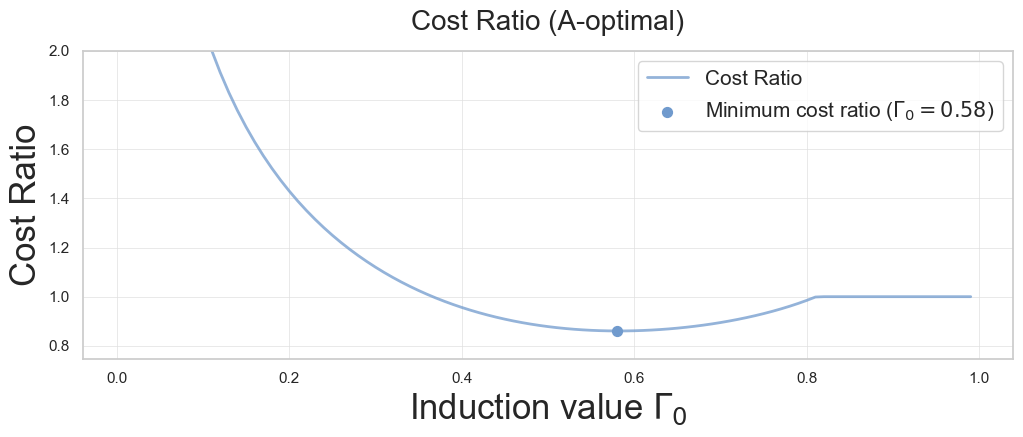

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the master functions from our cost module
from minimum_cost import min_cost_design

# 1. Configuración ESTRICTA de la estética de la tesis
sns.set_theme(
    style="whitegrid", 
    rc={
        "axes.grid": True,
        "grid.color": "#e0e0e0", 
        "grid.linewidth": 0.5,
        "axes.facecolor": "white" 
    }
)

colores = {
    'r': '#bf775f', 'r2': '#d5572c', 'o': "#e38800", 'y': '#e6d26b',
    'g': "#648B00", 'c': '#98cacd', 'b': '#709acd', 'p': "#645697",  
    'gr': '#444444', 'b2': '#4c72b0'
}

# 2. Define a simple and direct baseline scenario
model_name = 'logistic'
gamma_val = 0.5
criterion_choice = 'A'

print(f"--- Minimum Cost Analysis for the {criterion_choice}-optimal Criterion ---")
print(f"Model: {model_name.capitalize()} | Gamma: {gamma_val}\n")

# 3. Calculate the minimum cost design and extract the curve
best_design, cost_series = min_cost_design(
    g=gamma_val, 
    model=model_name, 
    criterion=criterion_choice, 
    return_cost=True
)

# 4. Extraction of numerical results
min_cost_ratio = cost_series.min()
best_g0 = cost_series.idxmin()

print(f"Maximum response value ($\Gamma_0$) found: {best_g0:.2f}")
print(f"Minimum cost ratio achieved: {min_cost_ratio:.4f}\n")
print("Minimum cost design (Probability -> Weight):")
print(best_design.round(3))

# 5. Visualization with THESIS AESTHETICS
fig, ax = plt.subplots(figsize=(12, 4))

# Plot the complete curve using thesis colors and opacity
ax.plot(cost_series.index, cost_series.values, color=colores['b'], alpha=0.75, lw=2, label='Cost Ratio')

# Explicitly mark the geometric minimum point using thesis aesthetic
ax.scatter([best_g0], [min_cost_ratio], color=colores['b'], s=50, zorder=3)

# Add the bold LaTeX text annotation exactly like in the thesis

# Academic formatting of the plot with thesis font sizes
ax.set_title(f'Cost Ratio ({criterion_choice}-optimal)', fontsize=20, pad=15)
ax.set_xlabel(r'Induction value $\Gamma_0$', size=25)
ax.set_ylabel('Cost Ratio', size=25)
ax.legend(['Cost Ratio','Minimum cost ratio ($\Gamma_0 = '+str(round(best_g0, 2))+'$)'], fontsize=15)
ax.set_ylim(min_cost_ratio - (2-min_cost_ratio)*0.1, 2)

plt.show()